# Student Performance & Career Path Prediction
### ML Project | Dataset: synthetic_student_dataset.csv

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 2. Load Dataset

In [4]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/synthetic_student_dataset.csv')
df.head()

,student_id,age,gender,course,previous_semester_gpa,study_hours_per_day,attendance_percentage,sleep_hours_per_day,assignment_completion_rate,study_medium,exam_difficulty,social_media_hours_per_day,analytical_skill,communication_skill,technical_skill,leadership_skill,creativity_skill,final_exam_score,career_path
0,1,20,Female,BBA,5.41,1.0,82,5.7,poor,self-study,moderate,2.8,outstanding,good,average,outstanding,outstanding,57.70,Business
1,2,22,Male,BCA,8.26,2.2,70,5.0,poor,online,hard,7.0,outstanding,average,poor,average,average,69.88,Research
2,3,20,Male,BBA,6.82,4.3,81,7.8,average,coaching,moderate,1.3,poor,average,poor,good,average,84.40,Public Service
3,4,18,Male,BCom,5.11,3.4,86,4.8,average,self-study,hard,0.1,outstanding,good,good,good,poor,72.75,Technology
4,5,24,Male,BBA,6.66,5.5,89,5.4,good,coaching,easy,3.4,poor,average,average,poor,good,88.01,Creative


In [5]:
df.shape

(1000, 19)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   age                         1000 non-null   int64  
 2   gender                      1000 non-null   object 
 3   course                      1000 non-null   object 
 4   previous_semester_gpa       1000 non-null   float64
 5   study_hours_per_day         1000 non-null   float64
 6   attendance_percentage       1000 non-null   int64  
 7   sleep_hours_per_day         1000 non-null   float64
 8   assignment_completion_rate  1000 non-null   object 
 9   study_medium                1000 non-null   object 
 10  exam_difficulty             1000 non-null   object 
 11  social_media_hours_per_day  1000 non-null   float64
 12  analytical_skill            1000 non-null   object 
 13  communication_skill         1000 n

In [7]:
df.describe()

,student_id,age,previous_semester_gpa,study_hours_per_day,attendance_percentage,sleep_hours_per_day,social_media_hours_per_day,final_exam_score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,21.040000,7.409250,5.364900,79.882000,6.443600,2.648500,86.507820
std,288.819436,1.965773,1.389633,2.707236,11.259167,1.462504,2.190748,11.681161
min,1.000000,18.000000,5.010000,0.500000,42.000000,4.000000,0.000000,40.000000
25%,250.750000,19.000000,6.187500,3.100000,72.750000,5.200000,0.400000,80.390000
50%,500.500000,21.000000,7.425000,5.400000,80.000000,6.300000,2.500000,93.830000
75%,750.250000,23.000000,8.632500,7.700000,88.000000,7.800000,4.400000,95.000000
max,1000.000000,24.000000,9.800000,10.000000,100.000000,9.000000,7.700000,95.000000


In [8]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
course,0
previous_semester_gpa,0
study_hours_per_day,0
attendance_percentage,0
sleep_hours_per_day,0
assignment_completion_rate,0
study_medium,0


## 3. Exploratory Data Analysis (EDA)

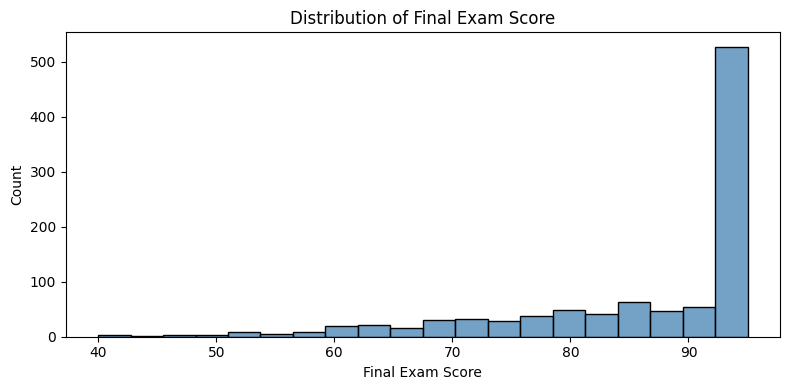

In [9]:
plt.figure(figsize=(8, 4))
sns.histplot(df['final_exam_score'], bins=20, color='steelblue')
plt.title('Distribution of Final Exam Score')
plt.xlabel('Final Exam Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

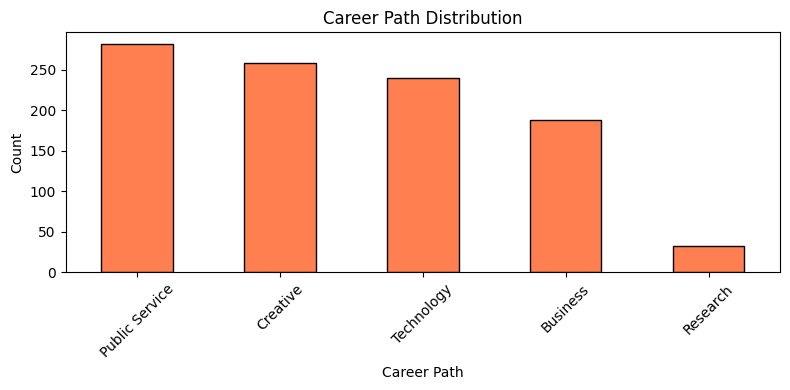

In [10]:
plt.figure(figsize=(8, 4))
df['career_path'].value_counts().plot(kind='bar', color='coral', edgecolor='black')
plt.title('Career Path Distribution')
plt.xlabel('Career Path')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

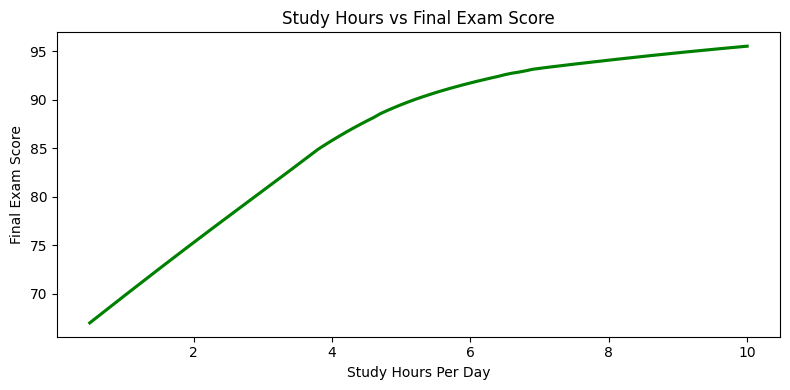

In [11]:
plt.figure(figsize=(8, 4))
sns.regplot(data=df, x='study_hours_per_day', y='final_exam_score',
            scatter=False, color='green', lowess=True)
plt.title('Study Hours vs Final Exam Score')
plt.xlabel('Study Hours Per Day')
plt.ylabel('Final Exam Score')
plt.tight_layout()
plt.show()

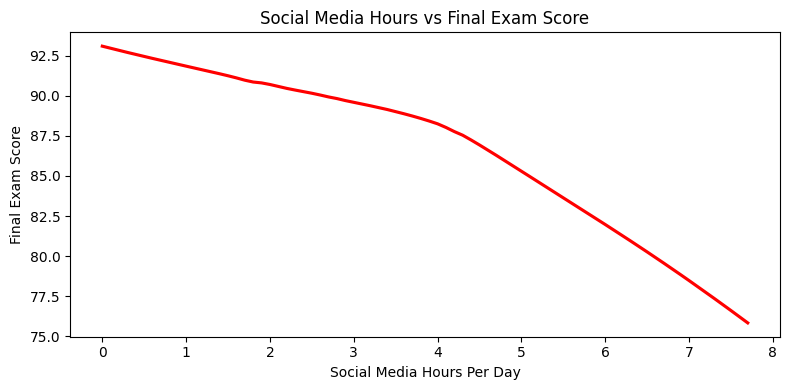

In [12]:
plt.figure(figsize=(8, 4))
sns.regplot(data=df, x='social_media_hours_per_day', y='final_exam_score',
            scatter=False, color='red', lowess=True)
plt.title('Social Media Hours vs Final Exam Score')
plt.xlabel('Social Media Hours Per Day')
plt.ylabel('Final Exam Score')
plt.tight_layout()
plt.show()

## 4. Preprocessing

In [13]:
df_clean = df.drop(columns=['student_id'])

cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
print('Categorical columns:', cat_cols)

le = LabelEncoder()
for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

df_clean.head()

Categorical columns: ['gender', 'course', 'assignment_completion_rate', 'study_medium', 'exam_difficulty', 'analytical_skill', 'communication_skill', 'technical_skill', 'leadership_skill', 'creativity_skill', 'career_path']


,age,gender,course,previous_semester_gpa,study_hours_per_day,attendance_percentage,sleep_hours_per_day,assignment_completion_rate,study_medium,exam_difficulty,social_media_hours_per_day,analytical_skill,communication_skill,technical_skill,leadership_skill,creativity_skill,final_exam_score,career_path
0,20,0,1,5.41,1.0,82,5.7,3,3,2,2.8,2,1,0,2,2,57.70,0
1,22,1,2,8.26,2.2,70,5.0,3,2,1,7.0,2,0,3,0,0,69.88,3
2,20,1,1,6.82,4.3,81,7.8,0,0,2,1.3,3,0,3,1,0,84.40,2
3,18,1,3,5.11,3.4,86,4.8,0,3,1,0.1,2,1,1,1,3,72.75,4
4,24,1,1,6.66,5.5,89,5.4,1,0,0,3.4,3,0,0,3,1,88.01,1


## 5. Model 1 — Final Exam Score Prediction (Linear Regression)

In [14]:
X_reg = df_clean.drop(columns=['final_exam_score', 'career_path'])
y_reg = df_clean['final_exam_score']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
print('Train size:', X_train_r.shape, '| Test size:', X_test_r.shape)

Train size: (800, 16) | Test size: (200, 16)


In [15]:
lr = LinearRegression()
lr.fit(X_train_r, y_train_r)

y_pred_r = lr.predict(X_test_r)

In [16]:
print('Linear Regression Results')
print('-' * 35)
print(f'MAE  : {mean_absolute_error(y_test_r, y_pred_r):.2f}')
print(f'MSE  : {mean_squared_error(y_test_r, y_pred_r):.2f}')
print(f'RMSE : {np.sqrt(mean_squared_error(y_test_r, y_pred_r)):.2f}')
print(f'R2   : {r2_score(y_test_r, y_pred_r):.4f}')

Linear Regression Results
-----------------------------------
MAE  : 4.74
MSE  : 37.52
RMSE : 6.13
R2   : 0.6837


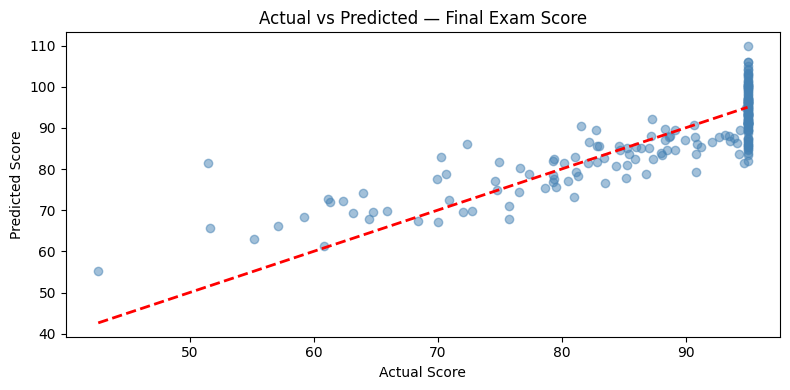

In [17]:
plt.figure(figsize=(8, 4))
plt.scatter(y_test_r, y_pred_r, alpha=0.5, color='steelblue')
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2)
plt.xlabel('Actual Score')
plt.ylabel('Predicted Score')
plt.title('Actual vs Predicted — Final Exam Score')
plt.tight_layout()
plt.show()

## 6. Model 2 — Career Path Prediction (Logistic Regression)

In [18]:
X_clf = df_clean.drop(columns=['career_path', 'final_exam_score'])
y_clf = df_clean['career_path']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)
print('Train size:', X_train_c.shape, '| Test size:', X_test_c.shape)

Train size: (800, 16) | Test size: (200, 16)


In [19]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_c, y_train_c)

y_pred_c = log_reg.predict(X_test_c)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [20]:
print('Logistic Regression Results')
print('-' * 35)
print(f'Accuracy : {accuracy_score(y_test_c, y_pred_c):.4f}')
print()
print(classification_report(y_test_c, y_pred_c))

Logistic Regression Results
-----------------------------------
Accuracy : 0.2600

              precision    recall  f1-score   support

           0       0.33      0.05      0.08        42
           1       0.27      0.45      0.34        51
           2       0.31      0.39      0.35        57
           3       0.00      0.00      0.00         6
           4       0.14      0.11      0.12        44

    accuracy                           0.26       200
   macro avg       0.21      0.20      0.18       200
weighted avg       0.26      0.26      0.23       200



## 7. Model Summary


In [21]:
print('=' * 45)
print('           MODEL SUMMARY')
print('=' * 45)
print(f'Linear Regression   R2 Score : {r2_score(y_test_r, y_pred_r):.4f}')
print(f'Logistic Regression Accuracy : {accuracy_score(y_test_c, y_pred_c):.4f}')
print('=' * 45)

           MODEL SUMMARY
Linear Regression   R2 Score : 0.6837
Logistic Regression Accuracy : 0.2600


# 8. Switch to Random Forest for better accuracy

In [23]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

In [24]:
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train_c, y_train_c)

rf_accuracy = rf_classifier.score(X_test_c, y_test_c)

In [28]:
print(f"Random Forest Accuracy       : {rf_accuracy:.4f}")

Random Forest Accuracy       : 0.9450


In [33]:
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train_r, y_train_r)

y_pred_rf = rf_regressor.predict(X_test_r)

In [34]:
print('RandomForestRegressor Results')
print('-' * 35)
print(f'MAE  : {mean_absolute_error(y_test_r, y_pred_rf):.2f}')
print(f'MSE  : {mean_squared_error(y_test_r, y_pred_rf):.2f}')
print(f'RMSE : {np.sqrt(mean_squared_error(y_test_r, y_pred_rf)):.2f}')
print(f'R2   : {r2_score(y_test_r, y_pred_rf):.4f}')

RandomForestRegressor Results
-----------------------------------
MAE  : 2.86
MSE  : 23.90
RMSE : 4.89
R2   : 0.7985


In [36]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf_regressor, X_train_r, y_train_r, cv=5)

print(scores.mean())

0.7878137504171076


# 9. CONCLUSION

In [41]:
print('=' * 45)
print('           MODEL SUMMARY')
print('=' * 45)
print(f'Linear Regression   R2 Score : {r2_score(y_test_r, y_pred_r):.4f}')
print(f'Logistic Regression Accuracy : {accuracy_score(y_test_c, y_pred_c):.4f}')
print('=' * 45)
print(f'RandomForestRegressor   R2 Score : {r2_score(y_test_r, y_pred_rf):.4f}')
print(f'RandomForestClassifier  Accuracy : {rf_classifier.score(X_test_c, y_test_c):.4f}')
print('=' * 45)

           MODEL SUMMARY
Linear Regression   R2 Score : 0.6837
Logistic Regression Accuracy : 0.2600
RandomForestRegressor   R2 Score : 0.7985
RandomForestClassifier  Accuracy : 0.9450


# 10. Export Models

In [42]:
import joblib

In [43]:
joblib.dump(rf_regressor, "marks_prediction_model.pkl")
joblib.dump(rf_classifier, "career_prediction_model.pkl")

['career_prediction_model.pkl']